# Figure 2 Jupyter Notebook

## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as tck
import glob
import os

from lmfit import Model
from lmfit.models import SineModel, ConstantModel, GaussianModel

## Subfigure (a): Coincidence Histogram

Importing, fitting

In [2]:
FILENAME = ('/Users/alexkolar/Library/CloudStorage/Box-Box/Zhonglab/Lab data/Ring Resonators'
            '/Unmounted_device_mk_3/2026_04_15/pair_generation/correlation_01.txt')
FITTING = True  # add a fit
integration_time = 2 * 60  # seconds


def g_2_exp_bg(x, x0, bg, amplitude, T_1, T_2):
    """Another fitting function for cavity decay.

    Fit as two exponentials with a constant background offset.

    Args:
        x (np.ndarray): time-domain x-values
        x0 (float): center of coincidence peak
        bg (float): value of accidental coincidences
        amplitude (float): amplitude of coincidence peak
        T_1 (float): decay constant for right (positive) side of peak
        T_2 (float): decay constant for left (negative) side of peak

    Return:
        np.ndarray: coincidence histogram
    """
    right_decay = np.heaviside(x-x0, 0.5) * np.exp(-(x-x0) / T_1)
    left_decay = np.heaviside(x0-x, 0.5) * np.exp(-(x0-x) / T_2)
    bg_arr = bg * np.ones_like(x)
    return (amplitude * right_decay) + (amplitude * left_decay) + bg_arr


# NOTE: first line of csv needs extra tab added
# otherwise the columns will not be read properly
df = pd.read_csv(FILENAME, sep='\t')
coincidence = df['Counts'] / integration_time
time_coincidence = df["Time(ps)"]  # unit: ps
time_coincidence *= 1e-3  # unit: ns
time_diff = time_coincidence[1] - time_coincidence[0]  # spacing of histogram

# fitting
model = Model(g_2_exp_bg)

x0_guess = 25
bg_guess = 1
amplitude_guess = 10
T_1_guess = 1
T_2_guess = 1

res_coincidence = model.fit(coincidence, x=time_coincidence,
                x0=x0_guess,
                bg=bg_guess,
                amplitude=amplitude_guess,
                T_1=T_1_guess,
                T_2=T_2_guess)
print(res_coincidence.fit_report())

[[Model]]
    Model(g_2_exp_bg)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 43
    # data points      = 10000
    # variables        = 5
    chi-square         = 218.561025
    reduced chi-square = 0.02186704
    Akaike info crit   = -38222.7510
    Bayesian info crit = -38186.6993
    R-squared          = 0.97336387
[[Variables]]
    x0:         25.1498296 +/- 0.00246722 (0.01%) (init = 25)
    bg:         2.33424398 +/- 0.00148503 (0.06%) (init = 1)
    amplitude:  27.5955819 +/- 0.06458267 (0.23%) (init = 10)
    T_1:        1.09164950 +/- 0.00502457 (0.46%) (init = 1)
    T_2:        1.01803018 +/- 0.00485191 (0.48%) (init = 1)
[[Correlations]] (unreported correlations are < 0.100)
    C(amplitude, T_1) = -0.5092
    C(x0, T_2)        = +0.5092
    C(amplitude, T_2) = -0.4918
    C(x0, T_1)        = -0.4918


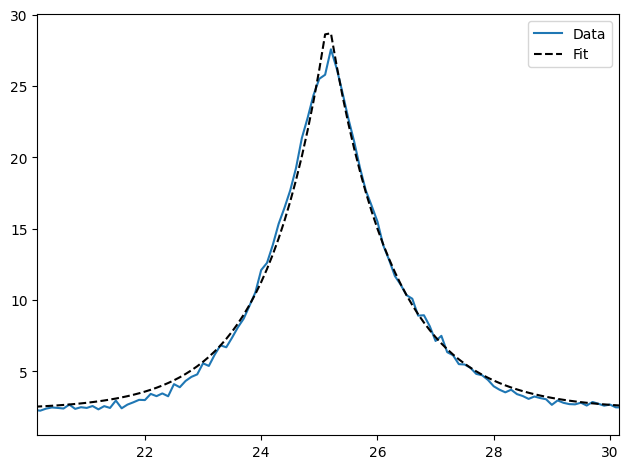

In [3]:
# plotting
plt.plot(time_coincidence, coincidence, label='Data')
time_to_plot = np.linspace(min(time_coincidence), max(time_coincidence), 10000)
plt.plot(time_to_plot, g_2_exp_bg(time_to_plot, **res_coincidence.best_values),
         'k--', label='Fit')

center = res_coincidence.params['x0'].value
xlim = (center - 5, center + 5)
plt.xlim(xlim)
plt.legend()
plt.tight_layout()
plt.show()

## Subfigure (b): Coincidence Rate and CAR

In [4]:
DATA_DIR = ('/Users/alexkolar/Library/CloudStorage/Box-Box/Zhonglab/Lab data/Ring Resonators'
            '/Unmounted_device_mk_3/2026_04_15/pair_generation')
POWER_FILE = ('/Users/alexkolar/Library/CloudStorage/Box-Box/Zhonglab/Lab data/Ring Resonators'
              '/Unmounted_device_mk_3/2026_04_15/pair_generation/correlation_power.csv')
file_fmt = 'correlation_{:02}.txt'
file_num_center_bin = 1
num_bins = 10  # number of bins to use for coincidence calculation
num_bins_exclude_bg = 200
integration_time = 2 * 60  # seconds

# power parameters
power_99 = 5320  # power measured at 99% arm of beamsplitter (in uW)
power_1 = 54.3  # power measured at 1% arm of beamsplitter (in uW)
power_ratio = power_99 / power_1

# efficiency parameters
snspd_52_efficiency = 0.4532 * 0.7274   # includes filter loss and detector inefficiency
snspd_48_efficiency = 0.4790 * 0.9260


# fitting function versus power
def quadratic(x, a):
    return a * (x ** 2)


# read power file
power_df = pd.read_csv(POWER_FILE)
file_numbers = power_df['File']

# get on-chip power
measured_bs_power = power_df['Beamsplitter Power (uW)']
input_power = measured_bs_power * power_ratio
output_power = power_df['Output Power (uW)']
total_efficiency = output_power / input_power
on_chip_power = np.sqrt(total_efficiency) * input_power
# print(np.sqrt(total_efficiency))
print(on_chip_power)

# loop over files
data_dfs = []
center_bin = 0
for file_num in file_numbers:
    file_path = os.path.join(DATA_DIR, file_fmt.format(file_num))
    data_df = pd.read_csv(file_path, sep='\t')
    data_dfs.append(data_df)

    if file_num == file_num_center_bin:
        center_bin = np.argmax(data_df['Counts'])
        print(f'Center bin: {center_bin}')
        print(f'Center time: {data_df["Time(ps)"][center_bin] * 1e-3:.2f} ns')

# extract coincidences and CAR
idx_start = center_bin - num_bins // 2
idx_end = center_bin + num_bins // 2 + 1
idx_bg_exclude_start = center_bin - num_bins_exclude_bg // 2
idx_bg_exclude_end = center_bin + num_bins_exclude_bg // 2 + 1
coincidences = []
car = []
for data_df in data_dfs:
    counts = np.sum(data_df['Counts'][idx_start:idx_end])
    coincidences.append(counts)

    num_bg_bins = len(data_df['Counts']) - num_bins_exclude_bg
    bg = np.sum(data_df['Counts'][:idx_bg_exclude_start]) + np.sum(data_df['Counts'][idx_bg_exclude_end:])
    bg /= num_bg_bins
    bg *= num_bins
    # print(f'Background: {bg:.2f}')
    car.append((counts - bg) / bg)

# fit coincidences
model = Model(quadratic)
coincidence_rate = np.array(coincidences) / integration_time
res_power = model.fit(coincidence_rate, x=on_chip_power,
                      a=0.5)
print(res_power.fit_report())

# fit coincidence rate on-chip
coincidence_rate_on_chip = coincidence_rate / (total_efficiency * snspd_48_efficiency * snspd_52_efficiency)
res_on_chip = model.fit(coincidence_rate_on_chip, x=on_chip_power/1e3, # convert to mW
                        a=3e5)
print(res_on_chip.fit_report())

0    1129.470092
1    1024.605423
2     910.125760
3     801.301947
4     687.365162
5     565.400411
6     455.221419
7     341.272400
8     222.861055
9     111.546966
dtype: float64
Center bin: 5252
Center time: 25.20 ns
[[Model]]
    Model(quadratic)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 5
    # data points      = 10
    # variables        = 1
    chi-square         = 1328.20438
    reduced chi-square = 147.578264
    Akaike info crit   = 50.8899812
    Bayesian info crit = 51.1925663
    R-squared          = 0.98036958
[[Variables]]
    a:  1.8954e-04 +/- 5.9189e-06 (3.12%) (init = 0.5)
[[Model]]
    Model(quadratic)
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 5
    # data points      = 10
    # variables        = 1
    chi-square         = 1.6287e+10
    reduced chi-square = 1.8097e+09
    Akaike info crit   = 214.110478
    Bayesian info crit = 214.413063
    R-squared          = 0.97638515
[[Variables]]
   

/var/folders/9s/1vly09jx3z36sfxgrw8bfrf80000gn/T/ipykernel_62782/2059737362.py:20: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


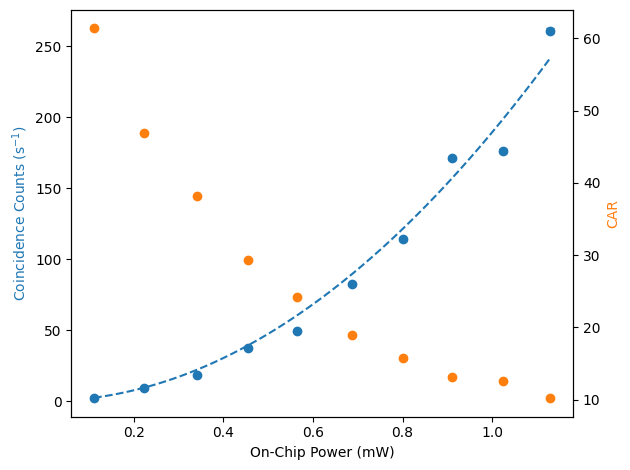

In [5]:
# final plotting
error = np.sqrt(coincidences) / integration_time
powers_for_fit = np.linspace(min(on_chip_power), max(on_chip_power), 100)
color_coincidences = 'tab:blue'
color_car = 'tab:orange'

fig, ax = plt.subplots()
ax_r = ax.twinx()
ax.errorbar(on_chip_power/1e3, coincidence_rate, yerr=error,
            capsize=3, marker='o', linestyle='', color=color_coincidences)
ax.plot(powers_for_fit/1e3, res_power.eval(x=powers_for_fit),
        color=color_coincidences, ls='--')
ax_r.plot(on_chip_power/1e3, car,
          color=color_car, marker='o', ls='')
ax.set_xlabel(r'On-Chip Power (mW)')
ax.set_ylabel(r'Coincidence Counts (s$^{-1}$)', color=color_coincidences)
ax_r.set_ylabel('CAR', color=color_car)

fig.tight_layout()
fig.show()

## Subfigre (c): AFC Storage

In [6]:
OFFRES_DATA = ('/Users/alexkolar/Library/CloudStorage/Box-Box/Zhonglab/Lab data/Ring Resonators'
               '/Mounted_device_mk_5/10mK/2026_04_08/afc/afc_storage_experiment_30db_offres.npz')
STORAGE_DATA = ('/Users/alexkolar/Library/CloudStorage/Box-Box/Zhonglab/Lab data/Ring Resonators'
                '/Mounted_device_mk_5/10mK/2026_04_08/afc/afc_storage_experiment_30db_storage.npz')

edge_coupling_efficiency = 0.07
snspd_efficiency = 0.5

# read data
data_offres = np.load(OFFRES_DATA, allow_pickle=True)
data_echo = np.load(STORAGE_DATA, allow_pickle=True)
time_storage = data_offres['bins']
time_diff = time_storage[1] - time_storage[0]

# calculate efficiencies
idx_in = np.where(np.logical_and(time_storage > 0.9, time_storage < 1.1))[0]
idx_echo = np.where(np.logical_and(time_storage > 1.9, time_storage < 2.1))[0]
counts_in = np.sum(data_offres['counts'][idx_in])
counts_echo = np.sum(data_echo['counts'][idx_echo])
print('Counts In:', counts_in)
print('Counts Echo:', counts_echo)
print('Efficiency:', counts_echo/counts_in)

# calculate pulse statistics
params = data_offres['storage parameters']
print(params)
# pulse_freq = data_offres['storage parameters']['pulse_freq']
# integration_time = data_offres['storage parameters']['integration_time']
integration_time = 300
pulse_freq = 100e3
num_pulses = integration_time * pulse_freq
total_photons = counts_in / edge_coupling_efficiency / snspd_efficiency
photons_per_pulse = total_photons / num_pulses
print('Total photons on chip:', total_photons)
print('Photons per pulse:', photons_per_pulse)

# fit data to gather reference 0 time
model = GaussianModel() + ConstantModel()
res_input_pulse = model.fit(data_offres['counts'], x=time_storage,
                            center=1)
print(res_input_pulse.fit_report())

Counts In: 197372
Counts Echo: 15265
Efficiency: 0.0773412642117423
{'integration_time': 300.0, 'bin_width': 1e-09, 'bin_number': 10000, 'pulse_freq': 100000.0, 'pulse_width': 6e-08, 'pulse_atten': 30.0, 'snspd_num': 2}
Total photons on chip: 5639199.999999999
Photons per pulse: 0.1879733333333333
[[Model]]
    (Model(gaussian) + Model(constant))
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 184
    # data points      = 10000
    # variables        = 4
    chi-square         = 1381280.44
    reduced chi-square = 138.183317
    Akaike info crit   = 49289.8111
    Bayesian info crit = 49318.6524
    R-squared          = 0.99917641
[[Variables]]
    amplitude:  198.455211 +/- 0.06983644 (0.04%) (init = 1)
    center:     0.96994275 +/- 2.6830e-06 (0.00%) (init = 1)
    sigma:      0.00661434 +/- 2.6845e-06 (0.04%) (init = 1)
    c:          0.05967889 +/- 0.11775866 (197.32%) (init = 0)
    fwhm:       0.01557557 +/- 6.3215e-06 (0.04%) == '2.3548200*sigma'
 

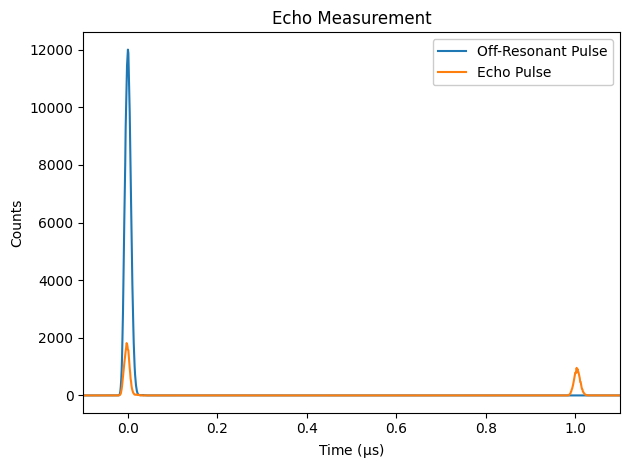

In [7]:
center_time = res_input_pulse.params['center'].value

# plotting overlaid
plt.plot(time_storage - center_time, data_offres['counts'],
         label='Off-Resonant Pulse')
plt.plot(time_storage - center_time, data_echo['counts'],
         label='Echo Pulse')

plt.title('Echo Measurement')
plt.xlabel(r'Time ($\mathrm{\mu}$s)')
plt.ylabel('Counts')
plt.legend(framealpha=1)
plt.xlim(-0.1, 1.1)

plt.tight_layout()
plt.show()

## Subfigure (d): AFC Coherence (Single)

In [8]:
DATA_DIR = ('/Users/alexkolar/Library/CloudStorage/Box-Box/Zhonglab/Lab data/Ring Resonators'
            '/Mounted_device_mk_5/10mK/2026_02_24/afc/afc_dual_comb_no_phase_offset')
one_pulse_offres = 'one_pulse_offres.txt'
one_pulse_storage = 'one_pulse_3_00pi.txt'
two_pulse_offres = 'two_pulse_offres.txt'
pi_to_plot_0 = 0.0
pi_to_plot_1 = 1.0

xlim_interfere = (1.99-0.2, 1.99+0.2)

# gather data
storage_files = glob.glob('two_pulse_*pi.txt', root_dir=DATA_DIR)
storage_files.sort()

# read data
df_0 = None
df_1 = None
for file in storage_files:
    file_path = os.path.join(DATA_DIR, file)
    file_parts = file.split('_')
    pi_fraction = float(file_parts[2]) + (float(file_parts[3][:2])/100)
    if pi_fraction == pi_to_plot_0:
        df_0 = pd.read_csv(file_path, sep='\t')
    elif pi_fraction == pi_to_plot_1:
        df_1 = pd.read_csv(file_path, sep='\t')

time_interfere = df_0['time(ps)']
time_interfere /= 1e6  # convert to us
counts_0 = df_0['counts']
counts_1 = df_1['counts']

idx_to_plot = (time_interfere > xlim_interfere[0]) & (time_interfere < xlim_interfere[1])
time_interfere = time_interfere[idx_to_plot]
counts_0 = counts_0[idx_to_plot]
counts_1 = counts_1[idx_to_plot]

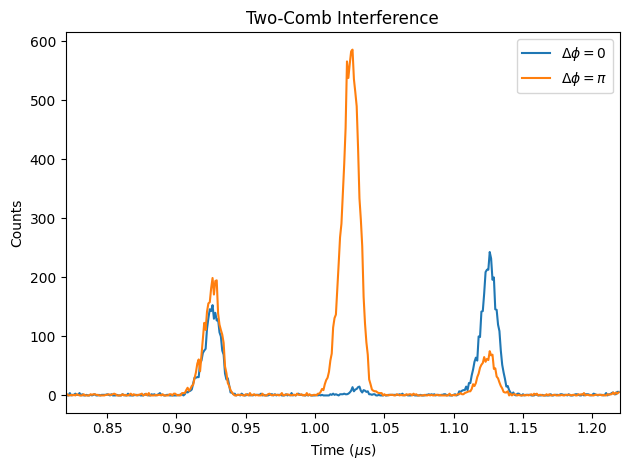

In [9]:
plt.plot(time_interfere-center_time, counts_0,
         label=r'$\Delta\phi = 0$')
plt.plot(time_interfere-center_time, counts_1,
         label=r'$\Delta\phi = \pi$')
plt.xlim(xlim_interfere-center_time)
plt.title('Two-Comb Interference')
plt.xlabel(r'Time ($\mu$s)')
plt.ylabel(r'Counts')
plt.legend()
plt.tight_layout()
plt.show()

## Subfigure (e): AFC Coherence (Sweep)

In [10]:
DATA_DIR = ('/Users/alexkolar/Library/CloudStorage/Box-Box/Zhonglab/Lab data/Ring Resonators'
            '/Mounted_device_mk_5/10mK/2026_02_24/afc/afc_dual_comb_no_phase_offset')  # contains sweep files
DATA_DIR_PHASE = ('/Users/alexkolar/Library/CloudStorage/Box-Box/Zhonglab/Lab data/Ring Resonators'
                  '/Mounted_device_mk_5/10mK/2026_02_24/afc/afc_dual_comb_half_pi_phase_offset')
one_pulse_offres = 'one_pulse_offres.txt'
one_pulse_storage = 'one_pulse_3_00pi.txt'
two_pulse_offres = 'two_pulse_offres.txt'
interference_window = (1.99-0.05, 1.99+0.05)

# plotting params
xlim = (1.97-0.2, 1.97+0.2)


# gather data
storage_files = glob.glob('two_pulse_*pi.txt', root_dir=DATA_DIR)
storage_files.sort()
storage_files_phase = glob.glob('two_pulse_*pi.txt', root_dir=DATA_DIR_PHASE)
storage_files_phase.sort()

dfs = []
all_phases = []
all_interference_counts = []
for file in storage_files:
    file_path = os.path.join(DATA_DIR, file)
    df = pd.read_csv(file_path, sep='\t')
    dfs.append(df)

    file_parts = file.split('_')
    pi_fraction = float(file_parts[2]) + (float(file_parts[3][:2])/100)
    all_phases.append(pi_fraction)

    time = df['time(ps)']
    time /= 1e6  # convert to us
    counts = df['counts']

    # gather relevant data
    int_idx = np.where(np.logical_and(time > interference_window[0], time < interference_window[1]))[0]
    interference_counts = np.sum(counts[int_idx])
    all_interference_counts.append(interference_counts)

dfs_phase = []
all_phases_phase = []
all_interference_counts_phase = []
for file in storage_files_phase:
    file_path = os.path.join(DATA_DIR_PHASE, file)
    df = pd.read_csv(file_path, sep='\t')
    dfs_phase.append(df)

    file_parts = file.split('_')
    pi_fraction = float(file_parts[4]) + (float(file_parts[5][:2])/100)
    all_phases_phase.append(pi_fraction)

    time = df['time(ps)']
    time /= 1e6  # convert to us
    counts = df['counts']

    # gather relevant data
    int_idx = np.where(np.logical_and(time > interference_window[0], time < interference_window[1]))[0]
    interference_counts = np.sum(counts[int_idx])
    all_interference_counts_phase.append(interference_counts)


# fitting
model = SineModel() + ConstantModel()
params = model.make_params(amplitude=4500, frequency=np.pi, c=4500)
params['frequency'].vary = False

# fit for no phase shift state
res = model.fit(all_interference_counts, params, x=all_phases)
print(res.fit_report())

amplitude = res.params['amplitude'].value
amplitude_err = res.params['amplitude'].stderr
constant = res.params['c'].value
constant_err = res.params['c'].stderr
visibility = amplitude/constant
visibility_err = visibility * np.sqrt((amplitude_err/amplitude)**2 + (constant_err/constant)**2)
print(f'Visibility: {visibility*100:.2f} +/- {visibility_err*100:.2f}%')
print(f'Fidelity: {(visibility+1)/2:.4f} +/- {visibility_err/2:.4f}')
maximum = (np.pi/2 - res.params['shift']) / res.params['frequency']
print(f'Calculated Maximum Point: {maximum}')

# fit for phase-shifted state
res_phase = model.fit(all_interference_counts_phase, params, x=all_phases_phase)
print(res_phase.fit_report())

amplitude = res_phase.params['amplitude'].value
amplitude_err = res_phase.params['amplitude'].stderr
constant = res_phase.params['c'].value
constant_err = res_phase.params['c'].stderr
visibility_phase = amplitude/constant
visibility_phase_err = visibility * np.sqrt((amplitude_err/amplitude)**2 + (constant_err/constant)**2)
print(f'Visibility: {visibility_phase*100:.2f} +/- {visibility_phase_err*100:.2f}%')
print(f'Fidelity: {(visibility_phase+1)/2:.4f} +/- {visibility_phase_err/2:.4f}')
maximum = (np.pi/2 - res_phase.params['shift']) / res_phase.params['frequency']
print(f'Calculated Maximum Point: {maximum}')

[[Model]]
    (Model(sine) + Model(constant))
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 30
    # data points      = 13
    # variables        = 3
    chi-square         = 258218.981
    reduced chi-square = 25821.8981
    Akaike info crit   = 134.655981
    Bayesian info crit = 136.350829
    R-squared          = 0.99814483
[[Variables]]
    amplitude:  4457.48308 +/- 60.7781592 (1.36%) (init = 4500)
    frequency:  3.141593 (fixed)
    shift:     -1.64396660 +/- 0.01529159 (0.93%) (init = 0)
    c:          4600.43892 +/- 46.3325946 (1.01%) (init = 4500)
[[Correlations]] (unreported correlations are < 0.100)
    C(shift, c) = -0.2728
Visibility: 96.89 +/- 1.64%
Fidelity: 0.9845 +/- 0.0082
Calculated Maximum Point: 1.023290821047007
[[Model]]
    (Model(sine) + Model(constant))
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 17
    # data points      = 13
    # variables        = 3
    chi-square         = 359037.318
    r

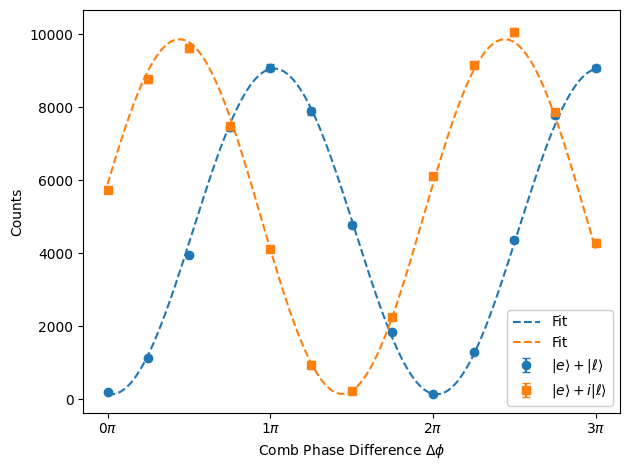

In [11]:
# final plotting of points and fitted fringe
x_points_for_eval = np.linspace(min(all_phases), max(all_phases), 1000)
plt.errorbar(all_phases, all_interference_counts, yerr=np.sqrt(all_interference_counts),
             color='tab:blue', ls='', marker='o', capsize=3,
             label=rf'$|e\rangle + |\ell\rangle$')
plt.plot(x_points_for_eval, res.eval(x=x_points_for_eval),
         color='tab:blue', ls='--',
         label='Fit')
plt.errorbar(all_phases_phase, all_interference_counts_phase, yerr=np.sqrt(all_interference_counts_phase),
             color='tab:orange', ls='', marker='s', capsize=3,
             label=rf'$|e\rangle + i|\ell\rangle$')
plt.plot(x_points_for_eval, res_phase.eval(x=x_points_for_eval),
         color='tab:orange', ls='--',
         label='Fit')
plt.xlabel(r'Comb Phase Difference $\Delta\phi$')
plt.ylabel('Counts')
plt.legend(framealpha=1)

ax = plt.gca()
ax.xaxis.set_major_formatter(tck.FormatStrFormatter(r'%g$\pi$'))
ax.xaxis.set_major_locator(tck.MultipleLocator(base=1.0))

plt.tight_layout()
plt.show()

# Main Plot Code

First, define plotting parameters

In [12]:
# matplotlib general (and font)
mpl.rcParams.update({'font.sans-serif': 'Arial',
                     'font.size': 8})
figsize = (8, 4)  # inches
dpi = 100
include_subplot_titles = False

# colors
color_primary = '#7570b3'
color_secondary = '#d95f02'
color_tertiary = '#1b9e77'

# figure layout
vertical_ratios = (1, 1.2)  # for two rows
horizontal_ratios_upper = (1, 1.5)
horizontal_ratios_lower = (1, 1, 2)
vertical_padding = 0.05
horizontal_padding = 0.05

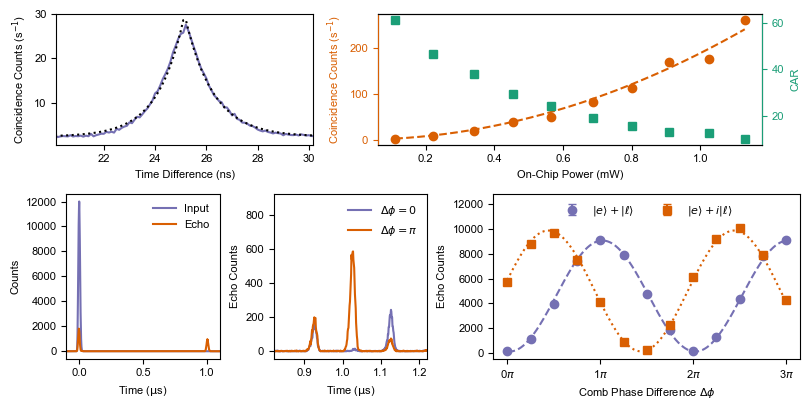

In [16]:
fig = plt.figure(layout='constrained', figsize=figsize, dpi=dpi)
fig.get_layout_engine().set(w_pad=horizontal_padding, h_pad=vertical_padding)
subfigs = fig.subfigures(2, 1, height_ratios=vertical_ratios)
axs_upper = subfigs[0].subplots(1, 2, width_ratios=horizontal_ratios_upper)
axs_lower = subfigs[1].subplots(1, 3, width_ratios=horizontal_ratios_lower)

# upper subplots
# subplot (a): Coincidence Histogram
axs_upper[0].plot(time_coincidence, coincidence,
                  color=color_primary,
                  label='Data')
# axs_upper[0].bar(time_coincidence, coincidence,
#                  width=time_coincidence[1]-time_coincidence[0],
#                  color=color_primary,)
time_to_plot = np.linspace(min(time_coincidence), max(time_coincidence), 10000)
axs_upper[0].plot(time_to_plot, g_2_exp_bg(time_to_plot, **res_coincidence.best_values),
                  color='k', ls=':',
                  label='Fit')
center = res_coincidence.params['x0'].value
xlim = (center - 5, center + 5)
axs_upper[0].set_xlim(xlim)
axs_upper[0].set_xlabel(r'Time Difference (ns)')
axs_upper[0].set_ylabel('Coincidence Counts (s$^{-1}$)')
# axs_upper[0].legend()

# subplot (b): Coincidence Rate
ax_car = axs_upper[1].twinx()
axs_upper[1].errorbar(on_chip_power/1e3, coincidence_rate, yerr=error,
                      marker='o', ls='', capsize=3, color=color_secondary)
power_to_plot = np.linspace(min(on_chip_power), max(on_chip_power), 1000)
axs_upper[1].plot(power_to_plot/1e3, res_power.eval(x=power_to_plot),
                  color=color_secondary, ls='--')
ax_car.plot(on_chip_power/1e3, car,
            marker='s', ls='', color=color_tertiary)
axs_upper[1].set_xlabel('On-Chip Power (mW)')
axs_upper[1].set_ylabel(r'Coincidence Counts (s$^{-1}$)', color=color_secondary)
ax_car.set_ylabel('CAR', color=color_tertiary)
ax_car.spines['left'].set_color(color_secondary)
ax_car.spines['right'].set_color(color_tertiary)
axs_upper[1].tick_params(axis='y', colors=color_secondary)
ax_car.tick_params(axis='y', colors=color_tertiary)
# axs_upper[1].legend()

# lower subplots
# subplot (c): AFC Storage
axs_lower[0].plot(data_offres['bins']-center_time, data_offres['counts'],
                  color=color_primary,
                  label='Input')
axs_lower[0].plot(data_offres['bins']-center_time, data_echo['counts'],
                  color=color_secondary,
                  label='Echo')
axs_lower[0].set_xlabel(r'Time ($\mathrm{\mu}$s)')
axs_lower[0].set_ylabel('Counts')
axs_lower[0].set_xlim(-0.1, 1.1)
axs_lower[0].legend(frameon=False)
# axs_lower[0].legend(bbox_to_anchor=(0, 1.02, 1., -.102), loc='lower center', ncols=2)

# subplot (d): AFC Interference
axs_lower[1].plot(time_interfere-center_time, counts_0,
                  label=r'$\Delta\phi = 0$', color=color_primary)
axs_lower[1].plot(time_interfere-center_time, counts_1,
                  label=r'$\Delta\phi = \pi$', color=color_secondary)
axs_lower[1].set_xlim(xlim_interfere - center_time)
old_ylim = axs_lower[1].get_ylim()
factor = 1.5
axs_lower[1].set_ylim(old_ylim[0]*factor, old_ylim[1]*factor)
axs_lower[1].set_xlabel(r'Time ($\mathrm{\mu}$s)')
axs_lower[1].set_ylabel(r'Echo Counts')
axs_lower[1].legend(frameon=False)
# axs_lower[1].legend(bbox_to_anchor=(0, 1.02, 1., -.102), loc='lower center', ncols=2)

# subplot (e): AFC Coherence
axs_lower[2].errorbar(all_phases, all_interference_counts, yerr=np.sqrt(all_interference_counts),
                      color=color_primary, ls='', marker='o', capsize=3,
                      label=rf'$|e\rangle + |\ell\rangle$')
axs_lower[2].plot(x_points_for_eval, res.eval(x=x_points_for_eval),
                  color=color_primary, ls='--')
                  # label='Fit')
axs_lower[2].errorbar(all_phases_phase, all_interference_counts_phase, yerr=np.sqrt(all_interference_counts_phase),
                      color=color_secondary, ls='', marker='s', capsize=3,
                      label=rf'$|e\rangle + i|\ell\rangle$')
axs_lower[2].plot(x_points_for_eval, res_phase.eval(x=x_points_for_eval),
                  color=color_secondary, ls=':')
                  # label='Fit')
old_ylim = axs_lower[2].get_ylim()
factor = 1.2
axs_lower[2].set_ylim(old_ylim[0]*factor, old_ylim[1]*factor)
axs_lower[2].set_xlabel(r'Comb Phase Difference $\Delta\phi$')
axs_lower[2].set_ylabel('Echo Counts')
axs_lower[2].legend(frameon=False, ncols=2, loc='upper center')
axs_lower[2].xaxis.set_major_formatter(tck.FormatStrFormatter(r'%g$\pi$'))
axs_lower[2].xaxis.set_major_locator(tck.MultipleLocator(base=1.0))
# axs_lower[2].legend(bbox_to_anchor=(0, 1.02, 1., -.102), loc='lower center', ncols=2)

In [17]:
fig.savefig('fig2.pdf')